# Table Access Protocol (TAP) queries: numeric output
Ref: [TAP](https://dp1.lsst.io/tutorials/notebook/102/notebook-102-1.html)

In [1]:
import numpy as np
from lsst.rsp import get_tap_service
import pandas as pd
import matplotlib.pyplot as plt
import time

service = get_tap_service ('tap')
assert service is not None

fields = pd.read_csv('LSSTComCam_fields.csv', index_col='field')

ddeg = .01
def grabcone(field):
    return "CONTAINS(POINT('ICRS', coord_ra, coord_dec), " +\
           f"CIRCLE('ICRS', {fields.loc[field, 'ra_deg']}, " +\
                          f"{fields.loc[field, 'dec_deg']}, {ddeg})) = 1"

In [2]:
queries = pd.DataFrame(columns=['select', 'from', 'where'])
queries.loc['columns'] = ["column_name, datatype, description, unit",
                          "tap_schema.columns",
                          "table_name = 'dp1.Object'"]
qcols = queries.columns

query = ''
for col in qcols:
    if queries.loc['columns'][col] != '':
        query += f' {col.upper()} {queries.loc['columns'][col]}'
print(query)

job = service.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
if job.phase == 'ERROR':
    job.raise_if_error()
elif job.phase == 'COMPLETED':
    out = job.fetch_result().to_table()

queries.loc['columns', 'out'] = out
print(type(out), len(out))
#       display(out)
print()

 SELECT column_name, datatype, description, unit FROM tap_schema.columns WHERE table_name = 'dp1.Object'
<class 'astropy.table.table.Table'> 1296



In [3]:
ocols = queries.loc['columns', 'out'].to_pandas()
ocols

,column_name,datatype,description,unit
0,coord_dec,double,Fiducial ICRS Declination of centroid used for...,deg
1,coord_decErr,float,Error in fiducial ICRS Declination of centroid,deg
2,coord_ra,double,Fiducial ICRS Right Ascension of centroid used...,deg
3,coord_ra_dec_Cov,float,Covariance between fiducial ICRS Right Ascensi...,deg**2
4,coord_raErr,float,Error in fiducial ICRS Right Ascension of cent...,deg
...,...,...,...,...
1291,z_raErr,float,"Error in right ascension, measured on z-band.",deg
1292,z_sersicFlux,float,z-band flux from the multiband Sersic model fit.,nJy
1293,z_sersicFluxErr,float,Error on the z-band flux from the multiband Se...,nJy
1294,z_sizeExtendedness,float,Moments-based measure of whether an object is ...,


In [4]:
ncols = ocols.loc[(ocols['datatype']!='boolean') & (ocols['datatype']!='char')]
ncols

,column_name,datatype,description,unit
0,coord_dec,double,Fiducial ICRS Declination of centroid used for...,deg
1,coord_decErr,float,Error in fiducial ICRS Declination of centroid,deg
2,coord_ra,double,Fiducial ICRS Right Ascension of centroid used...,deg
3,coord_ra_dec_Cov,float,Covariance between fiducial ICRS Right Ascensi...,deg**2
4,coord_raErr,float,Error in fiducial ICRS Right Ascension of cent...,deg
...,...,...,...,...
1290,z_ra_dec_Cov,float,Covariance between right ascension and declina...,deg**2
1291,z_raErr,float,"Error in right ascension, measured on z-band.",deg
1292,z_sersicFlux,float,z-band flux from the multiband Sersic model fit.,nJy
1293,z_sersicFluxErr,float,Error on the z-band flux from the multiband Se...,nJy


In [5]:
fcols = ['ra', 'dec', 'centroid_x', 'centroid_y', 'psfMag', 'cModelMag', 'psfFlux', 'cModelFlux', 'epoch']

queries['field'] = ''
for field in fields.index:
    for col in ['coord_ra', 'coord_dec', 'tract', 'patch', 'ebv']: # ncols['column_name'].values
        queries.loc[f'{col}_{field}'] = [col, "dp1.Object", grabcone(field), '', field]
    for col in fcols:
        for ff in ['u', 'g', 'r', 'i', 'z', 'y']:
            queries.loc[f'{ff}_{col}_{field}'] = [f'{ff}_{col}', "dp1.Object", grabcone(field), '', field]

for idx, dat in queries.iloc[1:].iterrows():
    query = ''
    for col in qcols:
        if dat[col] != '':
                query += f'{col.upper()} {dat[col]} '

    job = service.submit_job(query)
    job.run()
    job.wait(phases=['COMPLETED', 'ERROR'])
    if job.phase == 'ERROR':
        job.raise_if_error()
    elif job.phase == 'COMPLETED':
        out = job.fetch_result().to_table().to_pandas()

    if 'count' not in queries.columns:
        dcols = out[dat['select']].describe().index
        queries[dcols] = np.nan
    queries.loc[idx, dcols] = out[dat['select']].describe().T
    time.sleep(2)

queries.to_csv('TAPdescribe.csv')

In [6]:
queries

,select,from,where,out,field,count,mean,std,min,25%,50%,75%,max
columns,"column_name, datatype, description, unit",tap_schema.columns,table_name = 'dp1.Object',"[[coord_dec, double, Fiducial ICRS Declination...",,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
coord_ra_47Tuc,coord_ra,dp1.Object,"CONTAINS(POINT('ICRS', coord_ra, coord_dec), C...",,47Tuc,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
coord_dec_47Tuc,coord_dec,dp1.Object,"CONTAINS(POINT('ICRS', coord_ra, coord_dec), C...",,47Tuc,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tract_47Tuc,tract,dp1.Object,"CONTAINS(POINT('ICRS', coord_ra, coord_dec), C...",,47Tuc,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patch_47Tuc,patch,dp1.Object,"CONTAINS(POINT('ICRS', coord_ra, coord_dec), C...",,47Tuc,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
g_epoch_Seagull_Nebula,g_epoch,dp1.Object,"CONTAINS(POINT('ICRS', coord_ra, coord_dec), C...",,Seagull_Nebula,14.0,60654.163313,0.151421,60653.889917,60654.112850,60654.196899,60654.281614,60654.312392
r_epoch_Seagull_Nebula,r_epoch,dp1.Object,"CONTAINS(POINT('ICRS', coord_ra, coord_dec), C...",,Seagull_Nebula,14.0,60654.535131,0.117358,60654.294189,60654.455481,60654.605051,60654.605051,60654.623276
i_epoch_Seagull_Nebula,i_epoch,dp1.Object,"CONTAINS(POINT('ICRS', coord_ra, coord_dec), C...",,Seagull_Nebula,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
z_epoch_Seagull_Nebula,z_epoch,dp1.Object,"CONTAINS(POINT('ICRS', coord_ra, coord_dec), C...",,Seagull_Nebula,14.0,60654.291714,0.000094,60654.291595,60654.291679,60654.291679,60654.291825,60654.291830


(30.0, 140.0)

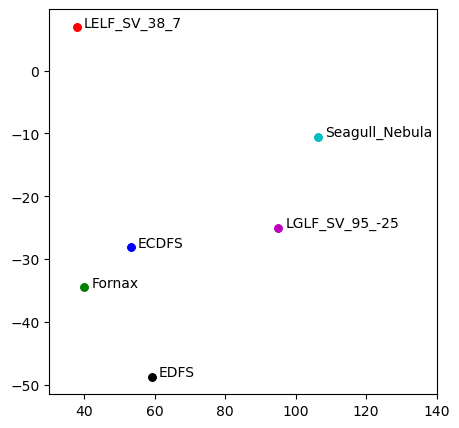

In [7]:
kala = ['y', 'r', 'g', 'b', 'k', 'm', 'c']
plt.figure(figsize=(5, 5))
for nfield, (field) in enumerate(fields.index):
    idx_ra = f'coord_ra_{field}'
    idx_dec = f'coord_dec_{field}'
    for col in ['min', 'mean', 'max']:
        ra = queries.loc[idx_ra, col]
        dec = queries.loc[idx_dec, col]
        plt.plot(ra, dec, marker='.', color=kala[nfield], ms=10)
    plt.annotate(field, (ra, dec), (ra+2, dec))
plt.xlim(30, 140)

In [8]:
epochs = queries.loc[queries['select'].str.contains('epoch')][['min', 'max']]
epochs

,min,max
u_epoch_47Tuc,NaN,NaN
g_epoch_47Tuc,NaN,NaN
r_epoch_47Tuc,NaN,NaN
i_epoch_47Tuc,NaN,NaN
z_epoch_47Tuc,NaN,NaN
y_epoch_47Tuc,NaN,NaN
u_epoch_LELF_SV_38_7,NaN,NaN
g_epoch_LELF_SV_38_7,60643.643155,60645.077330
r_epoch_LELF_SV_38_7,60641.665781,60643.243717
i_epoch_LELF_SV_38_7,60640.249266,60641.012635
